# Lesson 5: Macroeconomics and Finance Models

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, PhD

## Where this lecture fits in the seven-lecture sequence

1. **Probability distributions and descriptive statistics**
2. **Hypothesis testing and experimental design**
3. **Relationships between variables, regression, and dependence**
4. **Simulation, time series, and risk measurement**
5. **Macroeconomics and finance models** ← *this lecture*
6. **Machine learning and prediction for business and finance**
7. **Integrated empirical project and model criticism**

This lecture connects the statistical tools from the first four lessons to core models in finance and macroeconomics. The common thread is valuation under uncertainty. We will study portfolio choice, CAPM, discounted cash flow valuation, capital structure, the Lucas tree model, the stochastic discount factor, the Hansen--Jagannathan bound, and a simple dynamic macro model.

## Learning objectives

By the end of this lecture, you should be able to:

1. Compute portfolio expected return, variance, volatility, and Sharpe ratio.
2. Solve a simple mean-variance portfolio problem in Python.
3. Explain why the CAPM market portfolio is a tangency portfolio in the standard model.
4. Build a discounted cash flow valuation using free cash flow and terminal value.
5. Explain how leverage affects return on equity, WACC, and bankruptcy risk.
6. Simulate a Lucas-tree-style stochastic discount factor.
7. Interpret the Hansen--Jagannathan bound as a restriction on asset-pricing models.
8. Construct and simulate a simple dynamic macroeconomic model.

## 1. Imports and notebook setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, root

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Mean-variance portfolio choice

Suppose there are $N$ risky assets. Let

$$
\boldsymbol{\mu} = E[\mathbf{R}]
$$

be the vector of expected returns and let

$$
\boldsymbol{\Sigma} = \operatorname{Var}(\mathbf{R})
$$

be the covariance matrix of returns. A portfolio is a vector of weights

$$
\mathbf{w} = (w_1,w_2,\ldots,w_N)'
$$

with weights that sum to one:

$$
\mathbf{1}'\mathbf{w}=1.
$$

The portfolio expected return and variance are

$$
E[R_p] = \mathbf{w}'\boldsymbol{\mu},
$$

and

$$
\sigma_p^2 = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}.
$$

The Sharpe ratio is

$$
S_p = \frac{E[R_p]-R_f}{\sigma_p},
$$

where $R_f$ is the risk-free rate. The tangency portfolio is the risky portfolio that maximizes the Sharpe ratio.

In [2]:
# Expected returns and covariance matrix for three risky assets
asset_names = ["Asset 1", "Asset 2", "Asset 3"]
mu = np.array([0.08, 0.12, 0.10])
Sigma = np.array([
    [0.04,  0.020, 0.010],
    [0.020, 0.050, 0.015],
    [0.010, 0.015, 0.030],
])
r_f = 0.03
n_assets = len(mu)

summary = pd.DataFrame({
    "Expected Return": mu,
    "Volatility": np.sqrt(np.diag(Sigma))
}, index=asset_names)
summary

,Expected Return,Volatility
Asset 1,0.0800,0.2000
Asset 2,0.1200,0.2236
Asset 3,0.1000,0.1732


In [3]:
def portfolio_return(weights, mu):
    return float(weights @ mu)

def portfolio_volatility(weights, Sigma):
    return float(np.sqrt(weights @ Sigma @ weights))

def sharpe_ratio(weights, mu, Sigma, r_f):
    vol = portfolio_volatility(weights, Sigma)
    if vol <= 0:
        return np.nan
    return (portfolio_return(weights, mu) - r_f) / vol

def negative_sharpe_ratio(weights, mu, Sigma, r_f):
    return -sharpe_ratio(weights, mu, Sigma, r_f)

constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n_assets))
initial_weights = np.ones(n_assets) / n_assets

result = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(mu, Sigma, r_f),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

w_tan = result.x
portfolio_table = pd.DataFrame({
    "Tangency Weight": w_tan
}, index=asset_names)

portfolio_table.loc["Portfolio", "Tangency Weight"] = portfolio_table["Tangency Weight"].sum()
portfolio_table

,Tangency Weight
Asset 1,0.0750
Asset 2,0.3918
Asset 3,0.5333
Portfolio,1.0000


In [4]:
tangency_return = portfolio_return(w_tan, mu)
tangency_vol = portfolio_volatility(w_tan, Sigma)
tangency_sharpe = sharpe_ratio(w_tan, mu, Sigma, r_f)

print(f"Tangency portfolio expected return: {tangency_return:.2%}")
print(f"Tangency portfolio volatility:       {tangency_vol:.2%}")
print(f"Tangency portfolio Sharpe ratio:     {tangency_sharpe:.3f}")

Tangency portfolio expected return: 10.63%
Tangency portfolio volatility:       15.71%
Tangency portfolio Sharpe ratio:     0.486


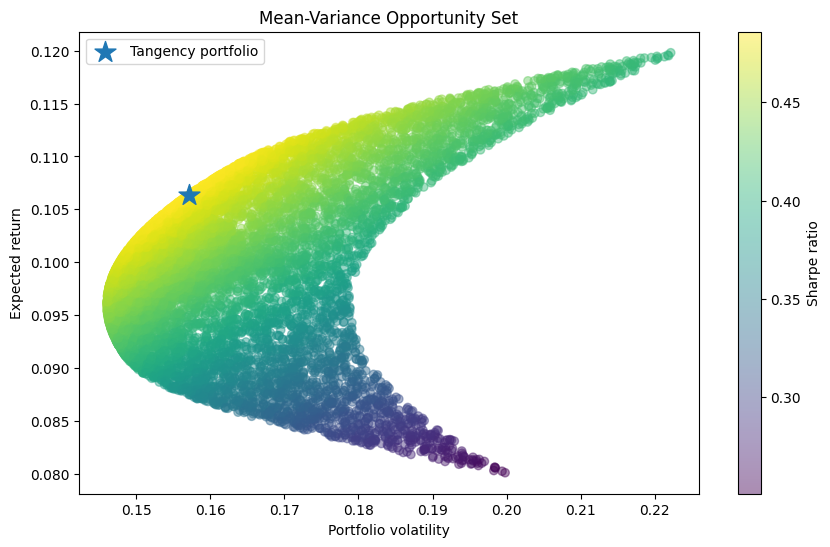

In [5]:
# Simulate many feasible long-only portfolios to visualize the opportunity set.
n_portfolios = 10_000
weights = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)
portfolio_returns = weights @ mu
portfolio_vols = np.sqrt(np.einsum("ij,jk,ik->i", weights, Sigma, weights))
portfolio_sharpes = (portfolio_returns - r_f) / portfolio_vols

plt.figure(figsize=(10, 6))
scatter = plt.scatter(portfolio_vols, portfolio_returns, c=portfolio_sharpes, alpha=0.45)
plt.colorbar(scatter, label="Sharpe ratio")
plt.scatter(tangency_vol, tangency_return, marker="*", s=250, label="Tangency portfolio")
plt.xlabel("Portfolio volatility")
plt.ylabel("Expected return")
plt.title("Mean-Variance Opportunity Set")
plt.legend()
plt.show()

## 3. CAPM intuition and beta

The Capital Asset Pricing Model states that expected excess returns are proportional to beta:

$$
E[R_i]-R_f = \beta_i\big(E[R_M]-R_f\big),
$$

where

$$
\beta_i = \frac{\operatorname{Cov}(R_i,R_M)}{\operatorname{Var}(R_M)}.
$$

In the standard CAPM, all investors share the same expectations, can borrow and lend at the same risk-free rate, and choose the same tangency portfolio of risky assets. In equilibrium, the aggregate risky portfolio held by investors is the market portfolio. Therefore, in that model, the market portfolio must be the tangency portfolio.

In [6]:
# Simulate asset returns and compute each asset's beta relative to the tangency portfolio.
n_periods = 1_000
simulated_asset_returns = np.random.multivariate_normal(mu, Sigma, size=n_periods)
df_returns = pd.DataFrame(simulated_asset_returns, columns=asset_names)
market_return = df_returns @ w_tan

betas = {}
for asset in asset_names:
    betas[asset] = np.cov(df_returns[asset], market_return, ddof=1)[0, 1] / np.var(market_return, ddof=1)

beta_table = pd.DataFrame.from_dict(betas, orient="index", columns=["Beta vs. Tangency Portfolio"])
beta_table

,Beta vs. Tangency Portfolio
Asset 1,0.6456
Asset 2,1.1828
Asset 3,0.9155


In [7]:
expected_excess = mu - r_f
market_excess = tangency_return - r_f
capm_predicted_excess = np.array(list(betas.values())) * market_excess

capm_table = pd.DataFrame({
    "Expected Excess Return": expected_excess,
    "CAPM-Predicted Excess Return": capm_predicted_excess,
    "Difference": expected_excess - capm_predicted_excess,
}, index=asset_names)
capm_table

,Expected Excess Return,CAPM-Predicted Excess Return,Difference
Asset 1,0.0500,0.0493,0.0007
Asset 2,0.0900,0.0903,-0.0003
Asset 3,0.0700,0.0699,0.0001


## 4. Gains to diversification: systematic and unsystematic risk

Diversification is one of the central ideas in modern portfolio theory. The variance of a portfolio is not the weighted average of the individual variances. It is the weighted average of all covariances:

$$
\sigma_p^2 = \sum_{i=1}^{N}\sum_{j=1}^{N} w_i w_j \sigma_{ij}.
$$

For an equally weighted portfolio with $N$ assets, common individual variance $\sigma^2$, and common pairwise correlation $\rho$, this becomes

$$
\sigma_p^2
= \frac{1}{N}\sigma^2 + \frac{N-1}{N}\rho\sigma^2.
$$

As $N$ rises, the first term declines toward zero. This is the diversifiable, idiosyncratic, or unsystematic component of risk. The second term remains when assets share common exposure to the same economy-wide forces. This is systematic risk.

A useful one-factor return model is

$$
R_{i,t} = \alpha_i + \beta_i F_t + \varepsilon_{i,t},
$$

where $F_t$ is the systematic factor and $\varepsilon_{i,t}$ is firm-specific noise. The expected return is

$$
E[R_i] = \alpha_i + \beta_i E[F_t],
$$

and the unexpected return is

$$
R_{i,t}-E[R_i]
= \beta_i\big(F_t-E[F_t]\big)+\varepsilon_{i,t}.
$$

Diversification can reduce the $\varepsilon_{i,t}$ part, but not the common factor exposure $\beta_i(F_t-E[F_t])$.

In [8]:
# Simulate a one-factor world to show how diversification reduces unsystematic risk.
np.random.seed(123)

T = 1_000
N = 60
factor_mean = 0.06
factor_vol = 0.16

# One systematic factor, such as the market return.
factor_returns = np.random.normal(factor_mean, factor_vol, size=T)

# Assets differ in beta, alpha, and idiosyncratic volatility.
alphas = np.random.normal(0.00, 0.01, size=N)
betas = np.random.normal(1.00, 0.25, size=N)
idiosyncratic_vols = np.random.uniform(0.10, 0.35, size=N)
idiosyncratic_shocks = np.random.normal(0, idiosyncratic_vols, size=(T, N))

asset_returns_factor = alphas + np.outer(factor_returns, betas) + idiosyncratic_shocks
asset_columns = [f"Asset {i+1}" for i in range(N)]
factor_returns_df = pd.DataFrame(asset_returns_factor, columns=asset_columns)

# Decompose realized returns into expected and unexpected components for illustration.
expected_returns_factor = alphas + betas * factor_mean
unexpected_returns_factor = factor_returns_df - expected_returns_factor

pd.DataFrame({
    "Alpha": alphas[:8],
    "Beta": betas[:8],
    "Idiosyncratic Volatility": idiosyncratic_vols[:8],
    "Expected Return": expected_returns_factor[:8],
}, index=asset_columns[:8])

,Alpha,Beta,Idiosyncratic Volatility,Expected Return
Asset 1,-0.0075,1.3330,0.2416,0.0725
Asset 2,0.0057,0.9021,0.2821,0.0598
Asset 3,0.0072,1.0527,0.1264,0.0703
Asset 4,-0.0100,0.9840,0.1696,0.0490
Asset 5,0.0047,1.1085,0.1522,0.0713
Asset 6,-0.0187,1.2201,0.2862,0.0545
Asset 7,-0.0020,1.0862,0.3339,0.0631
Asset 8,-0.0113,1.0864,0.2062,0.0538


In [9]:
# Build equally weighted portfolios with an increasing number of assets.
portfolio_sizes = np.arange(1, N + 1)
realized_portfolio_vols = []
systematic_vols = []
unsystematic_vols = []

for n in portfolio_sizes:
    w = np.ones(n) / n
    selected_returns = asset_returns_factor[:, :n]
    selected_betas = betas[:n]
    selected_idio_vols = idiosyncratic_vols[:n]

    portfolio_returns_n = selected_returns @ w
    realized_portfolio_vols.append(np.std(portfolio_returns_n, ddof=1))

    beta_p = w @ selected_betas
    systematic_var = (beta_p ** 2) * (factor_vol ** 2)
    unsystematic_var = np.sum((w ** 2) * (selected_idio_vols ** 2))

    systematic_vols.append(np.sqrt(systematic_var))
    unsystematic_vols.append(np.sqrt(unsystematic_var))

diversification_table = pd.DataFrame({
    "Number of Assets": portfolio_sizes,
    "Realized Portfolio Volatility": realized_portfolio_vols,
    "Systematic Volatility Component": systematic_vols,
    "Unsystematic Volatility Component": unsystematic_vols,
})

diversification_table.head(10)

,Number of Assets,Realized Portfolio Volatility,Systematic Volatility Component,Unsystematic Volatility Component
0,1,0.3123,0.2133,0.2416
1,2,0.2489,0.1788,0.1857
2,3,0.2092,0.1754,0.1308
3,4,0.1921,0.1709,0.1069
4,5,0.1868,0.1722,0.0907
5,6,0.1915,0.1760,0.0894
6,7,0.1904,0.1757,0.0903
7,8,0.1888,0.1755,0.0831
8,9,0.1912,0.1793,0.0792
9,10,0.1865,0.1768,0.0721


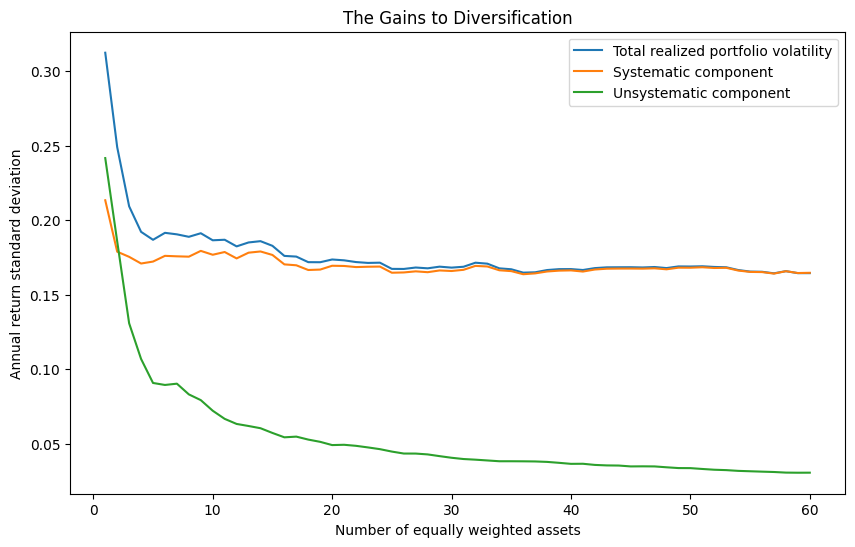

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(diversification_table["Number of Assets"], diversification_table["Realized Portfolio Volatility"], label="Total realized portfolio volatility")
plt.plot(diversification_table["Number of Assets"], diversification_table["Systematic Volatility Component"], label="Systematic component")
plt.plot(diversification_table["Number of Assets"], diversification_table["Unsystematic Volatility Component"], label="Unsystematic component")
plt.xlabel("Number of equally weighted assets")
plt.ylabel("Annual return standard deviation")
plt.title("The Gains to Diversification")
plt.legend()
plt.show()

The lesson from the graph is simple but powerful. Adding assets sharply reduces the idiosyncratic part of portfolio volatility at first. After the portfolio is already broadly diversified, adding more assets has a smaller effect because the remaining volatility is mostly systematic.

This is why CAPM prices beta rather than total volatility. Investors do not need to be compensated for bearing diversifiable risk if they can remove it by holding diversified portfolios. They do need compensation for bearing systematic risk because it cannot be diversified away.

## 5. Portfolio performance measures: Sharpe, Treynor, Jensen alpha, and information ratio

Markowitz optimization uses expected returns, variances, and covariances. Sharpe's CAPM adds the distinction between total risk and systematic risk. Portfolio performance measures use these ideas in different ways.

The **Sharpe ratio** measures excess return per unit of total volatility:

$$
\text{Sharpe}_p = \frac{E[R_p]-R_f}{\sigma_p}.
$$

The **Treynor ratio** measures excess return per unit of systematic risk:

$$
\text{Treynor}_p = \frac{E[R_p]-R_f}{\beta_p}.
$$

**Jensen's alpha** is the return in excess of the CAPM-predicted return:

$$
\alpha_p
= E[R_p] - \left(R_f + \beta_p(E[R_M]-R_f)\right).
$$

The **information ratio** compares active return to tracking error:

$$
\text{IR}_p = \frac{E[R_p-R_B]}{\sigma(R_p-R_B)},
$$

where $R_B$ is a benchmark return.

In [11]:
# Compare several portfolios using common performance measures.
market_proxy = factor_returns
risk_free_rate = 0.03
benchmark_return = market_proxy

candidate_portfolios = {
    "Single Asset 1": np.r_[1, np.zeros(N - 1)],
    "Equal Weight 5": np.r_[np.ones(5) / 5, np.zeros(N - 5)],
    "Equal Weight 20": np.r_[np.ones(20) / 20, np.zeros(N - 20)],
    "Equal Weight 60": np.ones(N) / N,
}

performance_rows = []
for name, w in candidate_portfolios.items():
    rp = asset_returns_factor @ w
    beta_p = np.cov(rp, market_proxy, ddof=1)[0, 1] / np.var(market_proxy, ddof=1)
    expected_rp = np.mean(rp)
    volatility_p = np.std(rp, ddof=1)
    excess_rp = expected_rp - risk_free_rate
    capm_required = risk_free_rate + beta_p * (np.mean(market_proxy) - risk_free_rate)
    active_return = rp - benchmark_return

    performance_rows.append({
        "Portfolio": name,
        "Expected Return": expected_rp,
        "Volatility": volatility_p,
        "Beta": beta_p,
        "Sharpe Ratio": excess_rp / volatility_p,
        "Treynor Ratio": excess_rp / beta_p,
        "Jensen Alpha": expected_rp - capm_required,
        "Information Ratio": np.mean(active_return) / np.std(active_return, ddof=1),
    })

performance_table = pd.DataFrame(performance_rows).set_index("Portfolio")
performance_table

,Expected Return,Volatility,Beta,Sharpe Ratio,Treynor Ratio,Jensen Alpha,Information Ratio
Portfolio,,,,,,,
Single Asset 1,0.0733,0.3123,1.2308,0.1387,0.0352,0.0142,0.0801
Equal Weight 5,0.0610,0.1868,1.0331,0.1662,0.0301,0.0066,0.0851
Equal Weight 20,0.0548,0.1736,1.0422,0.1428,0.0238,0.0001,0.0234
Equal Weight 60,0.0557,0.1644,1.0085,0.1563,0.0255,0.0018,0.0665


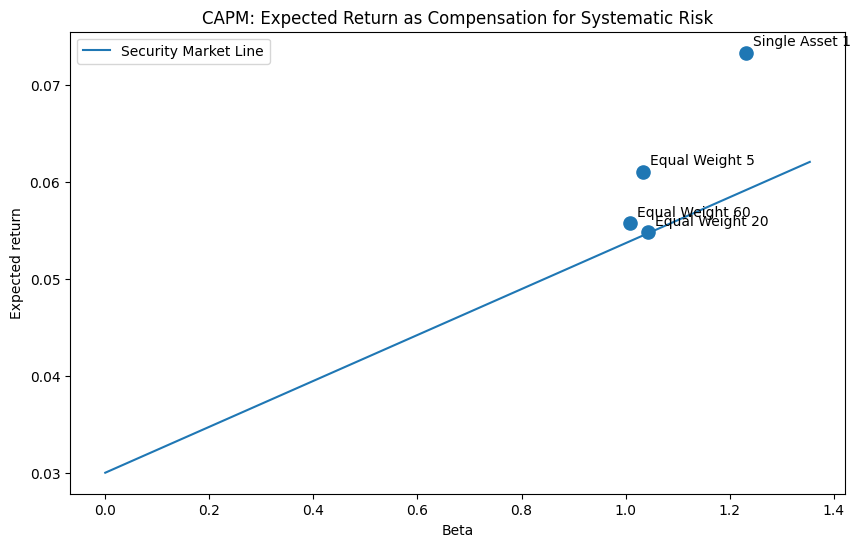

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(performance_table["Beta"], performance_table["Expected Return"], s=90)

for portfolio_name, row in performance_table.iterrows():
    ax.annotate(portfolio_name, (row["Beta"], row["Expected Return"]), xytext=(5, 5), textcoords="offset points")

beta_line = np.linspace(0, performance_table["Beta"].max() * 1.10, 100)
security_market_line = risk_free_rate + beta_line * (np.mean(market_proxy) - risk_free_rate)
ax.plot(beta_line, security_market_line, label="Security Market Line")

ax.set_xlabel("Beta")
ax.set_ylabel("Expected return")
ax.set_title("CAPM: Expected Return as Compensation for Systematic Risk")
ax.legend()
plt.show()

The measures answer different questions:

- **Markowitz** asks how to combine assets to obtain the best risk-return tradeoff using the whole covariance matrix.
- **Sharpe ratio** asks how much excess return a portfolio earns per unit of total volatility.
- **Treynor ratio** asks how much excess return a portfolio earns per unit of beta.
- **Jensen's alpha** asks whether a portfolio earned more than CAPM says it should have earned.
- **Information ratio** asks whether active management added return relative to a benchmark after accounting for tracking error.

These are not substitutes. They emphasize different notions of risk. A poorly diversified portfolio can have a high expected return but a weak Sharpe ratio because it carries too much avoidable volatility. A well-diversified portfolio may look better under Sharpe and Treynor because it strips out unsystematic risk and concentrates the analysis on compensated systematic risk.

## 6. Discounted cash flow valuation

A discounted cash flow model values an asset by forecasting future free cash flows and discounting them back to the present. A common free cash flow formula is

$$
FCF_t = EBIT_t(1-T_c) + Dep_t - CapEx_t - \Delta NWC_t.
$$

If free cash flows after the explicit forecast horizon grow at a constant rate $g$, the terminal value at date $T$ is

$$
TV_T = \frac{FCF_{T+1}}{r-g} = \frac{FCF_T(1+g)}{r-g}.
$$

The present value is

$$
PV = \sum_{t=1}^{T}\frac{FCF_t}{(1+r)^t}+\frac{TV_T}{(1+r)^T}.
$$

In [13]:
years_hist = np.array([2020, 2021, 2022, 2023])
revenue = np.array([100, 120, 140, 160], dtype=float)
expenses = np.array([70, 85, 100, 115], dtype=float)
depreciation = np.array([5, 6, 7, 8], dtype=float)
capex = np.array([10, 12, 14, 16], dtype=float)
delta_nwc = np.array([2, 3, 4, 5], dtype=float)
tax_rate = 0.25

ebit = revenue - expenses - depreciation
nopat = ebit * (1 - tax_rate)
fcf_hist = nopat + depreciation - capex - delta_nwc

historical_data = pd.DataFrame({
    "Revenue": revenue,
    "Expenses": expenses,
    "Depreciation": depreciation,
    "EBIT": ebit,
    "NOPAT": nopat,
    "CapEx": capex,
    "Change in NWC": delta_nwc,
    "Free Cash Flow": fcf_hist,
}, index=years_hist)

historical_data

,Revenue,Expenses,Depreciation,EBIT,NOPAT,CapEx,Change in NWC,Free Cash Flow
2020,100.0000,70.0000,5.0000,25.0000,18.7500,10.0000,2.0000,11.7500
2021,120.0000,85.0000,6.0000,29.0000,21.7500,12.0000,3.0000,12.7500
2022,140.0000,100.0000,7.0000,33.0000,24.7500,14.0000,4.0000,13.7500
2023,160.0000,115.0000,8.0000,37.0000,27.7500,16.0000,5.0000,14.7500


In [14]:
def dcf_valuation(
    starting_revenue,
    forecast_years=5,
    revenue_growth=0.10,
    expense_ratio=0.70,
    depreciation_ratio=0.05,
    capex_ratio=0.08,
    nwc_ratio=0.02,
    tax_rate=0.25,
    discount_rate=0.12,
    terminal_growth=0.03,
):
    if discount_rate <= terminal_growth:
        return np.nan, None
    years = np.arange(1, forecast_years + 1)
    forecast_revenue = starting_revenue * (1 + revenue_growth) ** years
    forecast_expenses = expense_ratio * forecast_revenue
    forecast_depreciation = depreciation_ratio * forecast_revenue
    forecast_capex = capex_ratio * forecast_revenue
    forecast_nwc = nwc_ratio * forecast_revenue
    forecast_ebit = forecast_revenue - forecast_expenses - forecast_depreciation
    forecast_nopat = forecast_ebit * (1 - tax_rate)
    forecast_fcf = forecast_nopat + forecast_depreciation - forecast_capex - forecast_nwc
    terminal_value = forecast_fcf[-1] * (1 + terminal_growth) / (discount_rate - terminal_growth)
    discounted_fcf = forecast_fcf / (1 + discount_rate) ** years
    discounted_terminal_value = terminal_value / (1 + discount_rate) ** forecast_years
    present_value = discounted_fcf.sum() + discounted_terminal_value
    details = pd.DataFrame({
        "Revenue": forecast_revenue,
        "EBIT": forecast_ebit,
        "NOPAT": forecast_nopat,
        "Free Cash Flow": forecast_fcf,
        "Discounted FCF": discounted_fcf,
    }, index=[2024 + i for i in range(forecast_years)])
    return present_value, {
        "details": details,
        "terminal_value": terminal_value,
        "discounted_terminal_value": discounted_terminal_value,
    }

base_pv, dcf_details = dcf_valuation(revenue[-1])
print(f"Base-case intrinsic value: ${base_pv:,.2f} million")
print(f"Terminal value at end of forecast horizon: ${dcf_details['terminal_value']:,.2f} million")
print(f"Discounted terminal value: ${dcf_details['discounted_terminal_value']:,.2f} million")
dcf_details["details"]

Base-case intrinsic value: $334.33 million
Terminal value at end of forecast horizon: $405.49 million
Discounted terminal value: $230.09 million


,Revenue,EBIT,NOPAT,Free Cash Flow,Discounted FCF
2024,176.0000,44.0000,33.0000,24.2000,21.6071
2025,193.6000,48.4000,36.3000,26.6200,21.2213
2026,212.9600,53.2400,39.9300,29.2820,20.8423
2027,234.2560,58.5640,43.9230,32.2102,20.4702
2028,257.6816,64.4204,48.3153,35.4312,20.1046


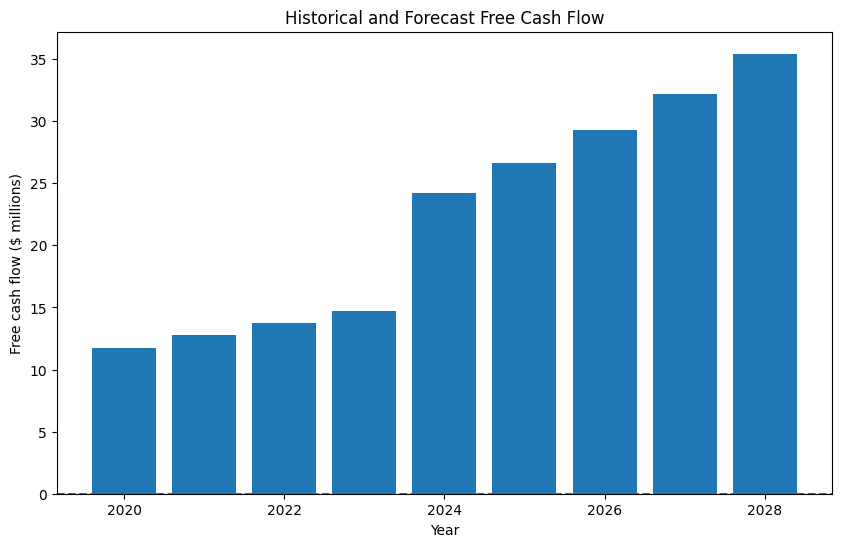

In [15]:
combined_years = list(years_hist) + list(dcf_details["details"].index)
combined_fcf = list(fcf_hist) + list(dcf_details["details"]["Free Cash Flow"])

plt.figure(figsize=(10, 6))
plt.bar(combined_years, combined_fcf)
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Free cash flow ($ millions)")
plt.title("Historical and Forecast Free Cash Flow")
plt.show()

In [16]:
# Sensitivity analysis: present value as a function of discount rate and terminal growth.
growth_grid = np.array([0.01, 0.02, 0.03, 0.04, 0.05])
discount_grid = np.array([0.08, 0.10, 0.12, 0.14, 0.16])

sensitivity = pd.DataFrame(index=[f"g={g:.0%}" for g in growth_grid], columns=[f"r={r:.0%}" for r in discount_grid])
for g in growth_grid:
    for r in discount_grid:
        pv, _ = dcf_valuation(revenue[-1], discount_rate=r, terminal_growth=g)
        sensitivity.loc[f"g={g:.0%}", f"r={r:.0%}"] = pv

sensitivity.astype(float)

,r=8%,r=10%,r=12%,r=14%,r=16%
g=1%,464.1931,356.8889,288.8426,241.9170,207.6499
g=2%,526.2003,390.5000,309.3128,255.3646,216.9681
g=3%,613.0103,433.7143,334.3319,271.2571,227.7200
g=4%,743.2253,491.3333,365.6057,290.3281,240.2638
g=5%,960.2504,572.0000,405.8150,313.6371,255.0883


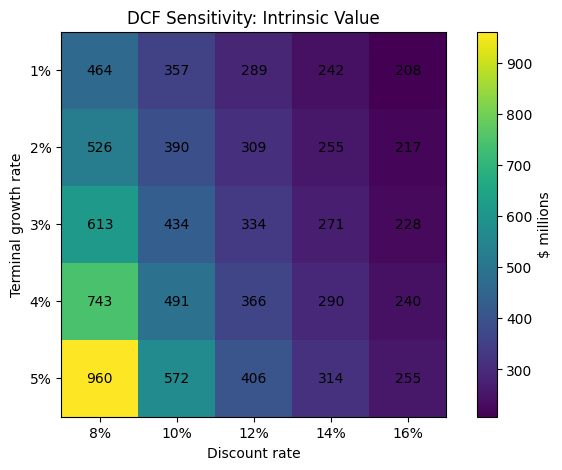

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(sensitivity.astype(float).values)
ax.set_xticks(np.arange(len(discount_grid)), labels=[f"{r:.0%}" for r in discount_grid])
ax.set_yticks(np.arange(len(growth_grid)), labels=[f"{g:.0%}" for g in growth_grid])
ax.set_xlabel("Discount rate")
ax.set_ylabel("Terminal growth rate")
ax.set_title("DCF Sensitivity: Intrinsic Value")
plt.colorbar(image, ax=ax, label="$ millions")
for i in range(len(growth_grid)):
    for j in range(len(discount_grid)):
        ax.text(j, i, f"{float(sensitivity.iloc[i, j]):.0f}", ha="center", va="center")
plt.show()

## 7. Monte Carlo DCF

The deterministic DCF hides model risk. A simple way to expose that uncertainty is to simulate many combinations of growth rates and discount rates.

The Monte Carlo valuation below draws

$$
g \sim \mathcal{N}(0.10,0.02^2),
$$

and

$$
r \sim \mathcal{N}(0.12,0.01^2),
$$

while requiring $r>g_T$, where $g_T$ is the terminal growth rate.

In [18]:
n_sims = 10_000
terminal_growth = 0.03
sim_growth = np.random.normal(0.10, 0.02, n_sims)
sim_discount = np.random.normal(0.12, 0.01, n_sims)

present_values = []
valid_growth = []
valid_discount = []
for g, r in zip(sim_growth, sim_discount):
    if r <= terminal_growth:
        continue
    pv, _ = dcf_valuation(revenue[-1], revenue_growth=g, discount_rate=r, terminal_growth=terminal_growth)
    if np.isfinite(pv):
        present_values.append(pv)
        valid_growth.append(g)
        valid_discount.append(r)

simulation_results = pd.DataFrame({
    "Present Value": present_values,
    "Revenue Growth": valid_growth,
    "Discount Rate": valid_discount,
})
simulation_results.describe()

,Present Value,Revenue Growth,Discount Rate
count,"10,000.0000","10,000.0000","10,000.0000"
mean,339.5380,0.1001,0.1201
std,48.8170,0.0202,0.0099
min,213.0383,0.0286,0.0807
25%,305.1688,0.0863,0.1133
50%,334.7334,0.0998,0.1200
75%,368.2370,0.1138,0.1268
max,668.3161,0.1727,0.1560


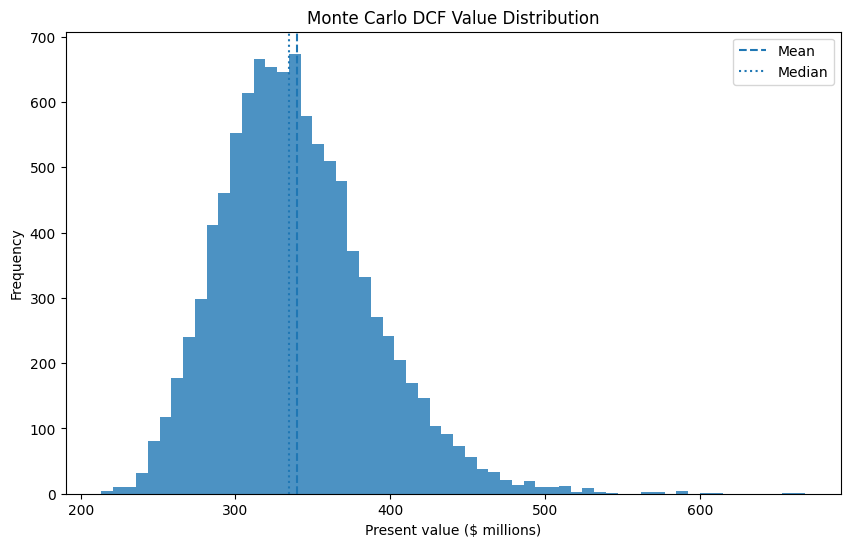

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(simulation_results["Present Value"], bins=60, alpha=0.8)
plt.axvline(simulation_results["Present Value"].mean(), linestyle="--", label="Mean")
plt.axvline(simulation_results["Present Value"].median(), linestyle=":", label="Median")
plt.xlabel("Present value ($ millions)")
plt.ylabel("Frequency")
plt.title("Monte Carlo DCF Value Distribution")
plt.legend()
plt.show()

## 8. Capital structure, leverage, and WACC

Leverage mechanically increases return on equity when operating returns exceed the cost of debt. With assets $A$, debt $D$, equity $E$, and return on assets $ROA$, the simple no-tax relation is

$$
ROE = ROA \times \frac{A}{E}.
$$

But leverage also increases financial distress risk. A basic weighted-average cost of capital is

$$
WACC = \frac{E}{V}R_E + \frac{D}{V}R_D(1-T_c),
$$

where $V=D+E$.

In [20]:
asset_value = 100.0
roa = 0.08
r_d = 0.05
t_c = 0.25
bankruptcy_cost_rate = 0.015

debt_to_equity = np.linspace(0, 5, 51)
capital_structure = []
for de in debt_to_equity:
    equity = asset_value / (1 + de)
    debt = asset_value - equity
    roe_no_cost = roa * asset_value / equity
    distress_penalty = bankruptcy_cost_rate * de * asset_value / equity
    roe_with_cost = roe_no_cost - distress_penalty
    r_e = roa + de * (roa - r_d) * (1 - t_c)
    wacc = (equity / asset_value) * r_e + (debt / asset_value) * r_d * (1 - t_c)
    adjusted_wacc = wacc + bankruptcy_cost_rate * de**2 / (1 + de)
    capital_structure.append([de, equity, debt, roe_no_cost, roe_with_cost, wacc, adjusted_wacc])

capital_structure = pd.DataFrame(capital_structure, columns=[
    "Debt/Equity", "Equity", "Debt", "ROE no distress cost", "ROE with distress cost", "WACC", "Adjusted WACC"
])
capital_structure.head()

,Debt/Equity,Equity,Debt,ROE no distress cost,ROE with distress cost,WACC,Adjusted WACC
0,0.0000,100.0000,0.0000,0.0800,0.0800,0.0800,0.0800
1,0.1000,90.9091,9.0909,0.0880,0.0864,0.0782,0.0783
2,0.2000,83.3333,16.6667,0.0960,0.0924,0.0767,0.0772
3,0.3000,76.9231,23.0769,0.1040,0.0982,0.0754,0.0764
4,0.4000,71.4286,28.5714,0.1120,0.1036,0.0743,0.0760


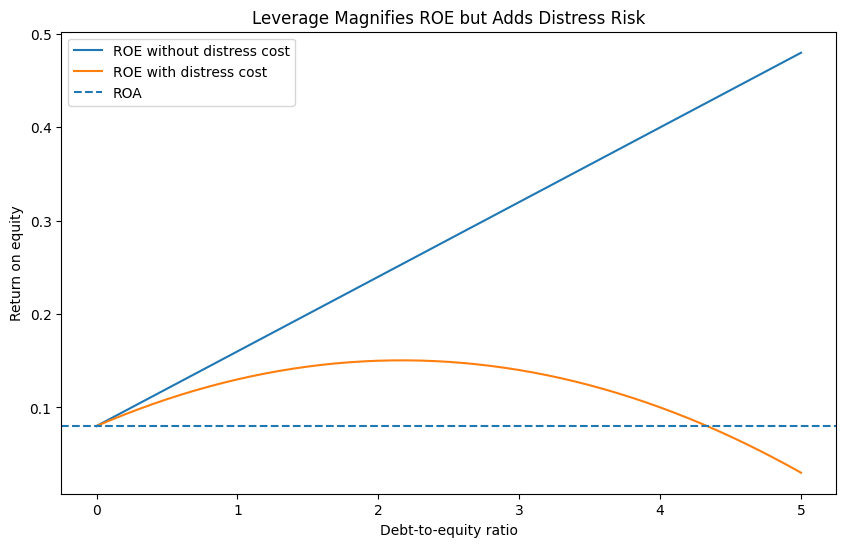

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(capital_structure["Debt/Equity"], capital_structure["ROE no distress cost"], label="ROE without distress cost")
plt.plot(capital_structure["Debt/Equity"], capital_structure["ROE with distress cost"], label="ROE with distress cost")
plt.axhline(roa, linestyle="--", label="ROA")
plt.xlabel("Debt-to-equity ratio")
plt.ylabel("Return on equity")
plt.title("Leverage Magnifies ROE but Adds Distress Risk")
plt.legend()
plt.show()

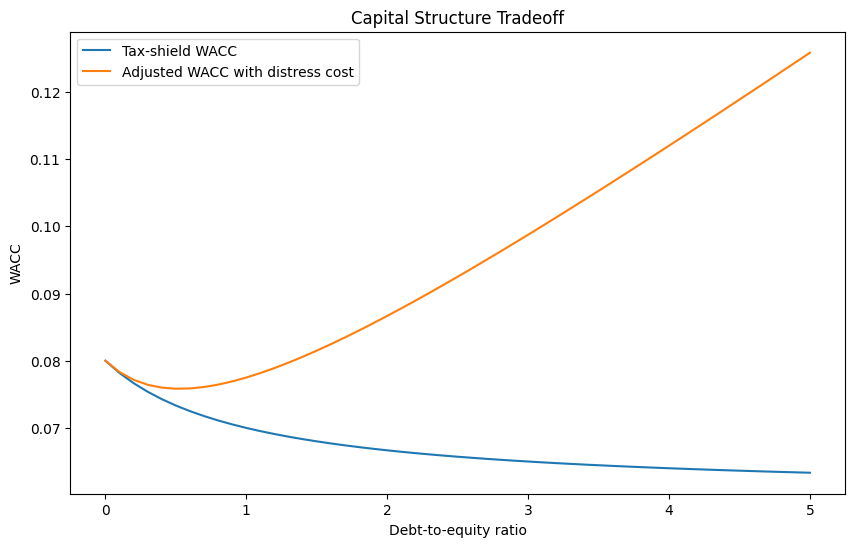

Debt/Equity     0.5000
Adjusted WACC   0.0758
Name: 5, dtype: float64

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(capital_structure["Debt/Equity"], capital_structure["WACC"], label="Tax-shield WACC")
plt.plot(capital_structure["Debt/Equity"], capital_structure["Adjusted WACC"], label="Adjusted WACC with distress cost")
plt.xlabel("Debt-to-equity ratio")
plt.ylabel("WACC")
plt.title("Capital Structure Tradeoff")
plt.legend()
plt.show()

idx = capital_structure["Adjusted WACC"].idxmin()
capital_structure.loc[idx, ["Debt/Equity", "Adjusted WACC"]]

## 9. A two-state leverage example

A two-state model makes the tradeoff more concrete. Suppose the firm has a success state and a failure state. Leverage increases equity returns in the success state but can wipe out equity in the failure state.

Expected equity return is

$$
E[ROE] = p_s ROE_s + (1-p_s)ROE_f.
$$

Expected firm value can be written schematically as

$$
V_L = V_U + PV(\text{tax shields}) - PV(\text{expected distress costs}).
$$

In [23]:
p_success = 0.80
revenue_success = 200
revenue_failure = 80
fixed_costs = 100
interest_rate = 0.05
debt_levels = np.array([0, 25, 50, 75, 100, 125, 150])
initial_assets = 200
bankruptcy_cost_pct = 0.20

rows = []
for debt in debt_levels:
    equity = initial_assets - debt
    interest = interest_rate * debt
    profit_success = revenue_success - fixed_costs - interest
    profit_failure = revenue_failure - fixed_costs - interest
    roe_success = max(profit_success / equity, -1) if equity > 0 else np.nan
    roe_failure = max(profit_failure / equity, -1) if equity > 0 else np.nan
    expected_roe = p_success * roe_success + (1 - p_success) * roe_failure
    distress_cost = max(0, fixed_costs + interest - revenue_failure) * bankruptcy_cost_pct
    firm_value = initial_assets + t_c * debt - (1 - p_success) * distress_cost
    rows.append([debt, equity, roe_success, roe_failure, expected_roe, distress_cost, firm_value])

two_state = pd.DataFrame(rows, columns=[
    "Debt", "Equity", "ROE Success", "ROE Failure", "Expected ROE", "Distress Cost in Failure", "Firm Value"
])
two_state

,Debt,Equity,ROE Success,ROE Failure,Expected ROE,Distress Cost in Failure,Firm Value
0,0,200,0.5000,-0.1000,0.3800,4.0000,199.2000
1,25,175,0.5643,-0.1214,0.4271,4.2500,205.4000
2,50,150,0.6500,-0.1500,0.4900,4.5000,211.6000
3,75,125,0.7700,-0.1900,0.5780,4.7500,217.8000
4,100,100,0.9500,-0.2500,0.7100,5.0000,224.0000
5,125,75,1.2500,-0.3500,0.9300,5.2500,230.2000
6,150,50,1.8500,-0.5500,1.3700,5.5000,236.4000


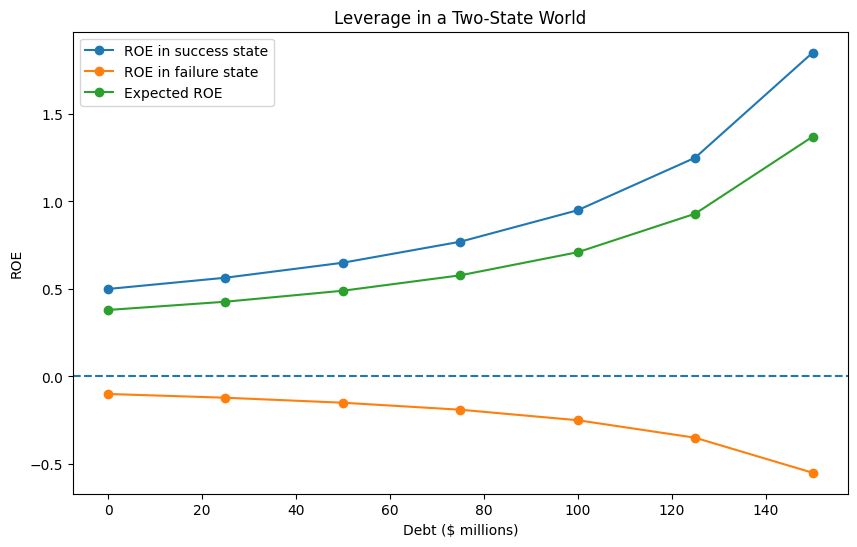

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(two_state["Debt"], two_state["ROE Success"], marker="o", label="ROE in success state")
plt.plot(two_state["Debt"], two_state["ROE Failure"], marker="o", label="ROE in failure state")
plt.plot(two_state["Debt"], two_state["Expected ROE"], marker="o", label="Expected ROE")
plt.axhline(0, linestyle="--")
plt.xlabel("Debt ($ millions)")
plt.ylabel("ROE")
plt.title("Leverage in a Two-State World")
plt.legend()
plt.show()

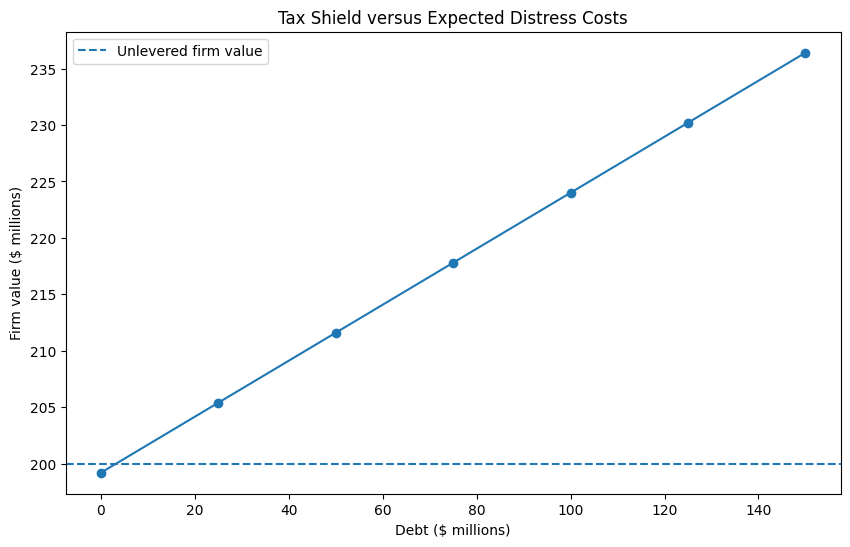

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(two_state["Debt"], two_state["Firm Value"], marker="o")
plt.axhline(initial_assets, linestyle="--", label="Unlevered firm value")
plt.xlabel("Debt ($ millions)")
plt.ylabel("Firm value ($ millions)")
plt.title("Tax Shield versus Expected Distress Costs")
plt.legend()
plt.show()

## 10. The Lucas tree model and the stochastic discount factor

The Lucas tree model is a foundational asset-pricing model. A representative agent owns a tree that produces a stochastic dividend. In a simple consumption-based asset-pricing model, the stochastic discount factor is

$$
M_{t+1}=\beta \left(\frac{C_{t+1}}{C_t}\right)^{-\gamma},
$$

where $\beta$ is the subjective discount factor and $\gamma$ is relative risk aversion. The basic asset-pricing equation is

$$
P_t = E_t[M_{t+1}X_{t+1}],
$$

where $X_{t+1}$ is the next-period payoff. For a risk-free asset,

$$
R_f = \frac{1}{E[M_{t+1}]}.
$$

In [26]:
beta = 0.98
gamma = 6.0
mu_g = 0.02
sigma_g = 0.03
n_simulations = 100_000

log_consumption_growth = np.random.normal(mu_g, sigma_g, n_simulations)
consumption_growth = np.exp(log_consumption_growth)
M = beta * consumption_growth ** (-gamma)

risk_free_return = 1 / M.mean() - 1
print(f"Risk-free return implied by the simulated SDF: {risk_free_return:.2%}")
print(f"Mean SDF: {M.mean():.4f}")
print(f"Std. dev. of SDF: {M.std():.4f}")

Risk-free return implied by the simulated SDF: 13.23%
Mean SDF: 0.8832
Std. dev. of SDF: 0.1601


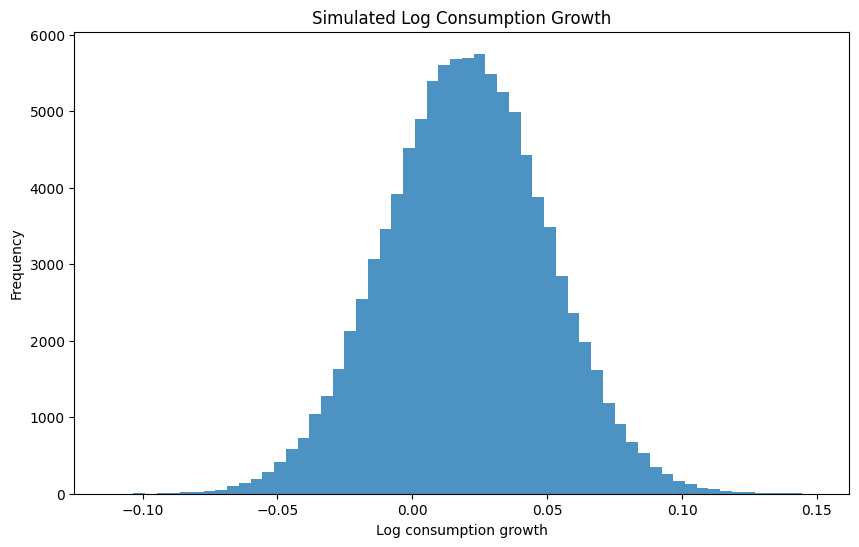

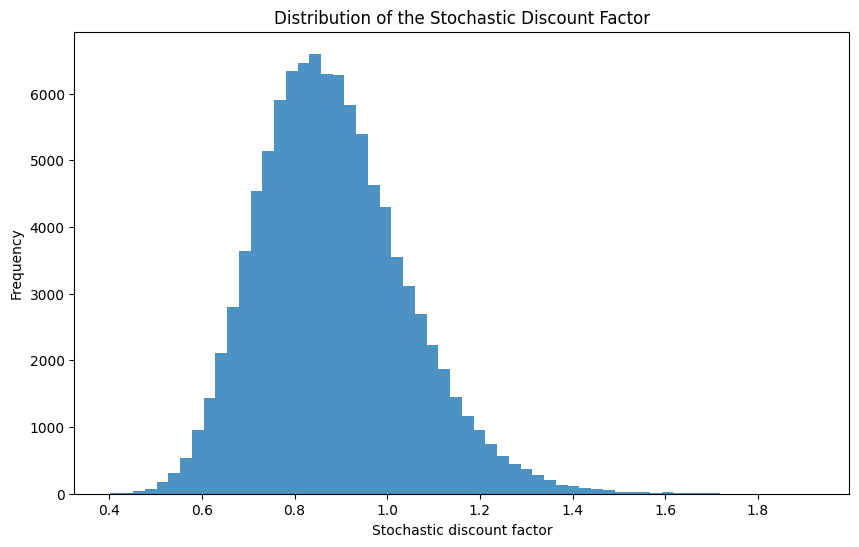

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(log_consumption_growth, bins=60, alpha=0.8)
plt.xlabel("Log consumption growth")
plt.ylabel("Frequency")
plt.title("Simulated Log Consumption Growth")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(M, bins=60, alpha=0.8)
plt.xlabel("Stochastic discount factor")
plt.ylabel("Frequency")
plt.title("Distribution of the Stochastic Discount Factor")
plt.show()

## 11. Hansen--Jagannathan bound

The Hansen--Jagannathan bound says that an admissible stochastic discount factor must be sufficiently volatile to price observed excess returns. For any excess return $R^e$,

$$
E[M R^e] = 0.
$$

This implies the bound

$$
\frac{\sigma(M)}{E[M]} \geq \frac{|E[R^e]|}{\sigma(R^e)},
$$

so the coefficient of variation of the SDF must be at least as large as the Sharpe ratio of the asset or portfolio being priced.

In [28]:
observed_equity_premium = 0.06
observed_equity_volatility = 0.18
observed_sharpe = observed_equity_premium / observed_equity_volatility
model_sdf_cv = M.std() / M.mean()

print(f"Observed equity Sharpe ratio: {observed_sharpe:.3f}")
print(f"Model SDF coefficient of variation: {model_sdf_cv:.3f}")
print(f"HJ bound satisfied? {model_sdf_cv >= observed_sharpe}")

Observed equity Sharpe ratio: 0.333
Model SDF coefficient of variation: 0.181
HJ bound satisfied? False


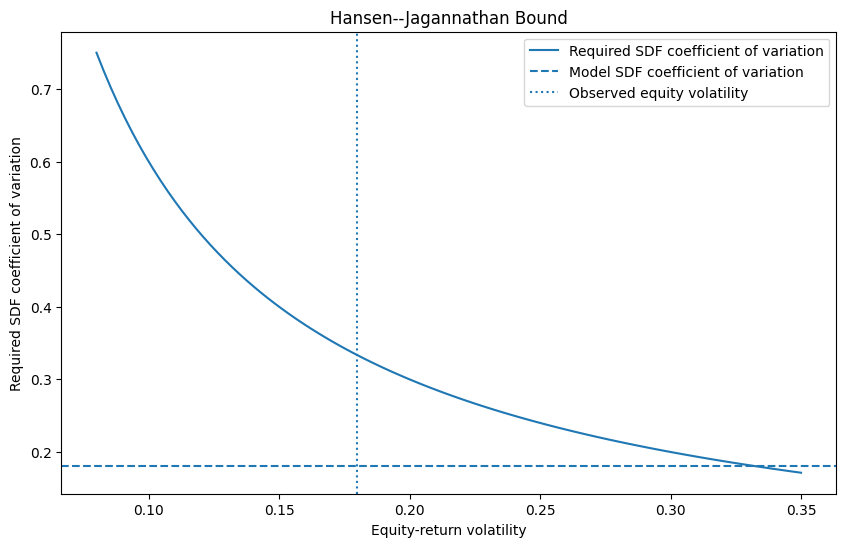

In [29]:
equity_vol_grid = np.linspace(0.08, 0.35, 100)
required_sdf_cv = observed_equity_premium / equity_vol_grid

plt.figure(figsize=(10, 6))
plt.plot(equity_vol_grid, required_sdf_cv, label="Required SDF coefficient of variation")
plt.axhline(model_sdf_cv, linestyle="--", label="Model SDF coefficient of variation")
plt.axvline(observed_equity_volatility, linestyle=":", label="Observed equity volatility")
plt.xlabel("Equity-return volatility")
plt.ylabel("Required SDF coefficient of variation")
plt.title("Hansen--Jagannathan Bound")
plt.legend()
plt.show()

## 12. A simple dynamic macroeconomic model

The final section gives a compact macroeconomic bridge. Consider a Cobb--Douglas economy with capital $K$, labor $L$, productivity $A$, and output

$$
Y_t = A_tK_t^\alpha L_t^{1-\alpha}.
$$

Capital evolves according to

$$
K_{t+1} = (1-\delta)K_t + I_t.
$$

A technology shock follows

$$
\log A_{t+1}=\rho_a \log A_t+\varepsilon_{t+1}.
$$

Rather than solve a full DSGE model with rational expectations, we use this system to simulate the mechanics of output, consumption, investment, capital accumulation, and productivity shocks.

In [30]:
alpha = 0.36
delta = 0.025
saving_rate = 0.22
rho_a = 0.90
sigma_a = 0.01
T = 120

K = np.zeros(T)
A = np.zeros(T)
Y = np.zeros(T)
I = np.zeros(T)
C = np.zeros(T)
L = np.ones(T)

K[0] = 50.0
A[0] = 1.0

for t in range(T - 1):
    Y[t] = A[t] * K[t] ** alpha * L[t] ** (1 - alpha)
    I[t] = saving_rate * Y[t]
    C[t] = Y[t] - I[t]
    log_A_next = rho_a * np.log(A[t]) + np.random.normal(0, sigma_a)
    A[t + 1] = np.exp(log_A_next)
    K[t + 1] = (1 - delta) * K[t] + I[t]

Y[-1] = A[-1] * K[-1] ** alpha
I[-1] = saving_rate * Y[-1]
C[-1] = Y[-1] - I[-1]

macro = pd.DataFrame({
    "Productivity": A,
    "Capital": K,
    "Output": Y,
    "Consumption": C,
    "Investment": I,
})
macro.head()

,Productivity,Capital,Output,Consumption,Investment
0,1.0000,50.0000,4.0891,3.1895,0.8996
1,1.0034,49.6496,4.0926,3.1922,0.9004
2,0.9962,49.3087,4.0533,3.1616,0.8917
3,1.0011,48.9677,4.0628,3.1690,0.8938
4,0.9934,48.6374,4.0221,3.1373,0.8849


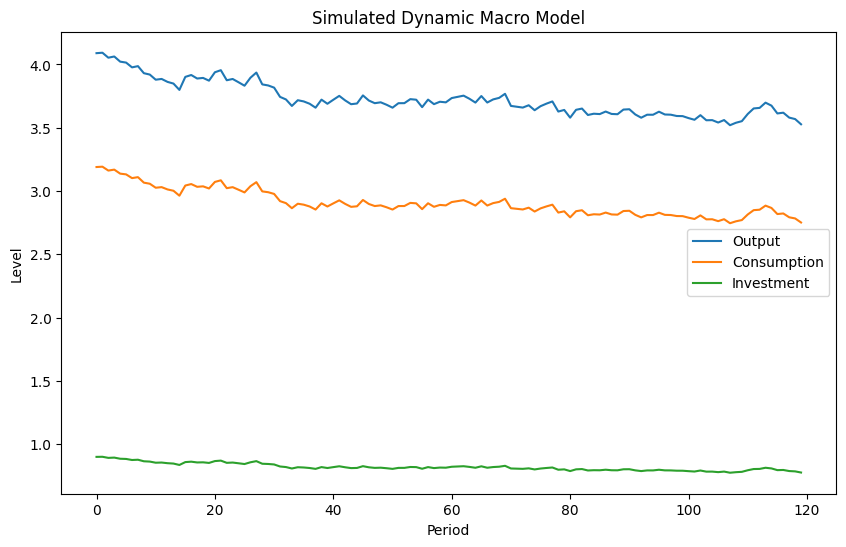

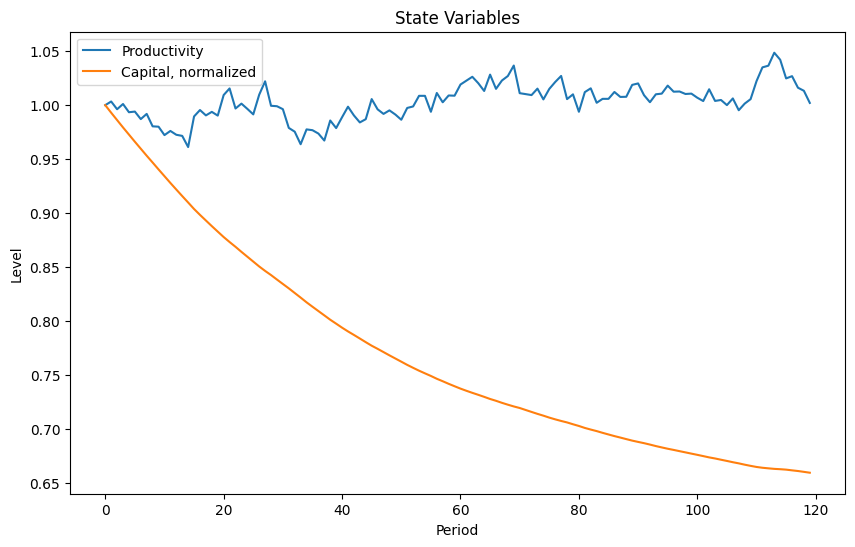

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(macro["Output"], label="Output")
plt.plot(macro["Consumption"], label="Consumption")
plt.plot(macro["Investment"], label="Investment")
plt.xlabel("Period")
plt.ylabel("Level")
plt.title("Simulated Dynamic Macro Model")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(macro["Productivity"], label="Productivity")
plt.plot(macro["Capital"] / macro["Capital"].iloc[0], label="Capital, normalized")
plt.xlabel("Period")
plt.ylabel("Level")
plt.title("State Variables")
plt.legend()
plt.show()

## 13. Optional: steady state of the deterministic capital accumulation model

In the deterministic version with $A=1$, $L=1$, and constant saving rate $s$, the steady state satisfies

$$
K^*=(1-\delta)K^*+s(K^*)^\alpha.
$$

Therefore,

$$
\delta K^* = s(K^*)^\alpha,
$$

and

$$
K^* = \left(\frac{s}{\delta}\right)^{\frac{1}{1-\alpha}}.
$$

In [32]:
K_star = (saving_rate / delta) ** (1 / (1 - alpha))
Y_star = K_star ** alpha
I_star = delta * K_star
C_star = Y_star - I_star

steady_state = pd.Series({
    "Capital steady state": K_star,
    "Output steady state": Y_star,
    "Investment steady state": I_star,
    "Consumption steady state": C_star,
})
steady_state

Capital steady state       29.9057
Output steady state         3.3984
Investment steady state     0.7476
Consumption steady state    2.6507
dtype: float64

## 14. Conclusion

This lecture used Python to connect several central models in finance and macroeconomics:

1. **Mean-variance optimization** gives a disciplined way to choose portfolios under risk.
2. **CAPM** links expected returns to systematic risk through beta.
3. **DCF valuation** converts accounting forecasts into present value.
4. **Capital structure models** show the tradeoff between tax shields, leverage, and expected distress costs.
5. **The Lucas tree model** introduces the stochastic discount factor as the bridge between macroeconomic risk and asset prices.
6. **The Hansen--Jagannathan bound** asks whether a model's SDF is volatile enough to explain observed risk premia.
7. **Dynamic macro simulation** shows how capital, output, consumption, investment, and productivity evolve through time.

The next lecture can build on these models by introducing predictive modeling, feature engineering, regularization, and machine learning tools for economic and financial data.

## Practice problems

1. Change the risk-free rate in the mean-variance section. How do the tangency weights change?
2. Allow short sales by changing the optimizer bounds. Does the Sharpe ratio rise?
3. In the DCF model, increase the terminal growth rate by one percentage point. How much does valuation change?
4. In the capital structure section, increase expected distress costs. What happens to the adjusted-WACC-minimizing debt ratio?
5. In the Lucas tree section, change risk aversion $\gamma$. How does the SDF volatility change?
6. In the macro simulation, lower the saving rate. What happens to the steady-state capital stock?